# Multimodal AI with Google Gemma 4 in KerasHub

**Authors:** Google DeepMind / Google AI  
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jggomez/workshop-open-models/blob/main/session-01-hf-kerashub-litert/01-kerashub-image-classification/02_gemma4_multimodal_ai.ipynb)

---

## Overview

**Gemma 4** is Google's next-generation family of open, lightweight multimodal foundation models built upon the research and technology used for the Gemini models.

### Key Capabilities of Gemma 4
Unlike earlier models that required separate pipelines for vision, speech, and tool use, Gemma 4 natively processes and unifies multiple modalities in a single causal decoder:
- **Native Vision Understanding:** Image captioning, multi-image comparison, visual question answering, and OCR.
- **Visual Grounding / Object Detection:** Native localization outputting precise bounding box coordinates `[ymin, xmin, ymax, xmax]` normalized to a `[0, 1000]` grid.
- **Native Audio Understanding:** Automatic speech recognition (ASR) directly transcribing audio waveforms without separate Whisper models.
- **Structured Tool Calling:** Native function calling syntax supporting tool declarations, parameter execution, and response synthesis.
- **Thinking Mode & Agentic Workflows:** Transparent chain-of-thought reasoning (`<|thought|>`) enabling autonomous multi-step planning and tool execution.

### Special Tokens Syntax
Gemma 4 uses a structured conversation format with specialized delimiter tokens:
- `<|turn>system\n...<turn|>`: System instructions and tool declarations.
- `<|turn>user\n...<turn|>`: User requests, containing optional modal markers:
  * `<|image|>`: Image input placeholder.
  * `<|audio|>`: Audio input placeholder.
- `<|turn>model\n...<turn|>`: Model response, containing optional thought and tool calls:
  * `<|thought|>`: Internal reasoning trace.
  * `<|tool>call:name{...}`: Tool invocation.
  * `<|tool>response:{...}`: Tool execution result.

---

## 1. Setup & Environment Dependencies

We install `keras-hub` along with multimedia processing libraries (`soundfile` and `scipy` for audio, `pillow` and `matplotlib` for vision, `av` for video containers):


In [ ]:
!pip install -q -U keras-hub
!pip install -q -U soundfile scipy requests pillow matplotlib av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.30.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 154.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "jax"  # or "tensorflow" or "torch"

import json
import re
from io import BytesIO

import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import requests
import soundfile as sf
from PIL import Image
import av

from IPython.display import Markdown, display

AUDIO_URL = (
    "https://raw.githubusercontent.com/keras-team/keras-hub/master/"
    "keras_hub/src/tests/test_data/audio_transcription_tests/"
    "female_short_voice_clip_17sec.wav"
)
IMAGE_URL = "http://images.cocodataset.org/val2017/000000039769.jpg"


## 2. Helper Utilities for Multimodal Inputs

We define helper functions to fetch, decode, and render multimodal inputs from URLs or local paths:
- `load_image(*sources)`: Downloads images, converts to RGB, and prepares tensors.
- `load_audio(*sources)`: Downloads audio, resamples waveforms to the model's required sample rate (16 kHz), and returns NumPy arrays.
- `display_images(*images, titles=...)`: Plots one or multiple images side by side with matplotlib.


In [ ]:

def load_image(*sources):
    """Load one or more images from URLs or local file paths."""

    def _load_one(source):
        if source.startswith(("http://", "https://")):
            response = requests.get(source, timeout=30)
            response.raise_for_status()
            return Image.open(BytesIO(response.content)).convert("RGB")
        return Image.open(source).convert("RGB")

    if not sources:
        return _load_one(IMAGE_URL)
    images = [_load_one(source) for source in sources]
    return images[0] if len(images) == 1 else images


def display_images(images, titles=None, figsize=(8, 6)):
    if not isinstance(images, (list, tuple)):
        images = [images]
    titles = titles or [None] * len(images)
    plt.figure(figsize=(figsize[0] * len(images), figsize[1]))
    for index, (image, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, len(images), index)
        plt.imshow(image)
        plt.axis("off")
        if title:
            plt.title(title)
    plt.show()


def load_audio(path):
    raw, sample_rate = sf.read(path)
    if raw.ndim > 1:
        raw = raw.mean(axis=1)
    if sample_rate != 16000:
        from scipy import signal

        raw = signal.resample(raw, int(len(raw) * 16000 / sample_rate))
    return raw.astype(np.float32)


def strip_prompt(output, prompt):
    if isinstance(output, list):
        output = output[0]
    if output.startswith(prompt):
        return output[len(prompt) :]
    for marker in ("<start_of_turn>model\n", "<|turn>model\n"):
        index = output.rfind(marker)
        if index != -1:
            return output[index + len(marker) :]
    return output


def display_model_response(text, title="Model response", language=None):
    cleaned = re.sub(r"<(?:turn\||channel\|)>", "", text).strip()
    display(Markdown(f"> **{title}**"))
    if language:
        display(Markdown(f"```{language}\n{cleaned}\n```"))
        return

    def demote_heading(match):
        hashes = match.group(1)
        return "#" * min(len(hashes) + 1, 6) + " "

    cleaned = re.sub(r"^(#{1,5})\s+", demote_heading, cleaned, flags=re.MULTILINE)
    display(Markdown(cleaned))


def extract_json_block(text):
    fenced_match = re.search(r"```json\s*(\[.*?\])\s*```", text, flags=re.DOTALL)
    if fenced_match:
        return json.loads(fenced_match.group(1))

    bracket_match = re.search(r"(\[\s*\{.*\}\s*\])", text, flags=re.DOTALL)
    if bracket_match:
        return json.loads(bracket_match.group(1))

    raise ValueError("Could not find a JSON detection block in the model output.")


def gemma_boxes_to_keras_prediction(image, detections):
    width, height = image.size
    label_to_id = {}
    boxes = []
    labels = []

    for detection in detections:
        label = detection.get("label", "object")
        if label not in label_to_id:
            label_to_id[label] = len(label_to_id)

        y_min, x_min, y_max, x_max = detection["box_2d"]
        boxes.append(
            [
                y_min / 1000.0 * height,
                x_min / 1000.0 * width,
                y_max / 1000.0 * height,
                x_max / 1000.0 * width,
            ]
        )
        labels.append(label_to_id[label])

    prediction = {
        "boxes": np.array([boxes], dtype="float32"),
        "labels": np.array([labels], dtype="int32"),
    }
    class_mapping = {value: key for key, value in label_to_id.items()}
    return prediction, class_mapping


def render_detection_result(image, raw_output):
    detections = extract_json_block(raw_output)
    prediction, class_mapping = gemma_boxes_to_keras_prediction(image, detections)
    image_batch = np.expand_dims(np.array(image), axis=0)

    rendered = keras.visualization.draw_bounding_boxes(
        image_batch,
        prediction,
        bounding_box_format="yxyx",
        class_mapping=class_mapping,
        color=(255, 235, 59),
        line_thickness=3,
        text_thickness=2,
        font_scale=0.8,
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(rendered[0].astype("uint8"))
    plt.axis("off")
    plt.show()
    return detections


## 3. Loading the Gemma 4 Multimodal Preset

We instantiate `keras_hub.models.Gemma4CausalLM.from_preset("gemma4_instruct_2b")`:
- **Model Preset:** `gemma4_instruct_2b` (2.3 Billion non-embedding parameters, 5.1 Billion parameters with vocabulary embeddings).
- **Instruction-Tuned:** Fine-tuned with RLHF/SFT for instruction following, chat dialogues, and agentic workflows.
- **Precision:** `dtype="bfloat16"` provides optimal numerical dynamic range and halves GPU VRAM usage compared to float32.


In [ ]:
print("Loading preset: gemma4_instruct_2b")
model = keras_hub.models.Gemma4CausalLM.from_preset(
    "gemma4_instruct_2b",
    dtype="bfloat16",
)


Loading preset: gemma4_instruct_2b


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'gemma4_causal_lm_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


## 4. Text Generation & Creative Ideation

We test text-only autoregressive generation using Gemma 4's turn-based conversation template:


In [ ]:
PROMPT_TEXT = (
    "<|turn>user\n"
    "Write a short, creative pitch for a movie about a time-traveling\n"
    "historian who accidentally changes the recipe for pizza.<turn|>\n"
    "<|turn>model\n"
)

text_output = model.generate({"prompts": [PROMPT_TEXT]}, max_length=512)
display_model_response(strip_prompt(text_output, PROMPT_TEXT))


> **Model response**

### Pizza Paradox

**Logline:** A meticulous historian, armed with a time machine, accidentally alters the very foundation of culinary history when a misplaced ingredient sends a pizza recipe spiraling into an unrecognizable, and utterly delicious, new reality.

**Pitch:**

Forget dinosaurs and dark lords. Our hero, Dr. Aris Thorne, isn't chasing empires—he's chasing *perfect* historical accuracy. Armed with a sleek, slightly temperamental time machine, Aris jumps through the centuries, meticulously documenting the past. But in a moment of temporal clumsiness, a rogue spice from the Renaissance lands in his modern kitchen, and the resulting pizza isn't just *good*—it's *revolutionary*.

Suddenly, the world tastes different. A Roman emperor might have a secret obsession with pepperoni, or perhaps the very concept of 'dough' is fundamentally altered. As Aris races against himself to fix the timeline before the world's pizza palate collapses into chaos, he discovers that sometimes, the greatest historical shifts aren't wars or revolutions—they're just a perfectly executed, slightly bizarre, accidental topping combination.

**Get ready for a delicious paradox. *Pizza Paradox* is the time-travel comedy-adventure where history is just a few slices away.**

## 5. Multimodal Vision: Image Captioning

Gemma 4 natively consumes visual tokens. We pass the `<|image|>` token in the prompt string, and provide the loaded image tensor in the `images=` parameter:


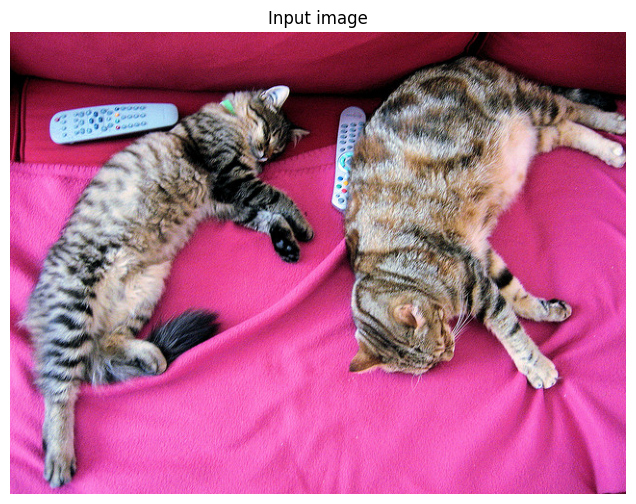

> **Model response**

This image features two tabby cats lying on a bright pink surface, likely a blanket or soft fabric.

Here's a detailed description:

*   **Subjects:** There are two cats.
    *   The cat on the left is a striped tabby with dark and gray markings. It is lying down and appears relaxed.
    *   The cat on the right is also a tabby, with warmer, brownish-orange tones. It is stretched out, with its head resting down, and appears to be grooming or resting.
*   **Setting/Background:** The cats are resting on a vibrant, solid **pink** surface. The fabric looks soft and plush.
*   **Objects:**
    *   Near the left cat, there is a white object that looks like a remote control or a similar electronic device with buttons.
    *   Near the right cat, there is a small, light-colored object that resembles a small remote or a piece of plastic.
*   **Mood:** The overall mood of the image is calm and cozy, suggesting a peaceful moment of rest for the cats.

In [ ]:
PROMPT_IMAGE = (
    "<|turn>user\n"
    "<|image|>\n"
    "Describe what you see in this image<turn|>\n"
    "<|turn>model\n"
)
image = load_image()
display_images(image, titles=["Input image"])

image_output = model.generate(
    {"prompts": [PROMPT_IMAGE], "images": [image]},
    max_length=2048,
)
display_model_response(strip_prompt(image_output, PROMPT_IMAGE))


## 6. Visual Grounding: Object Detection & Spatial Localization

Gemma 4 can localize objects in an image by returning bounding box coordinates in the normalized `[ymin, xmin, ymax, xmax]` format on a 0-1000 coordinate grid:


> **Model response**

```json
[
  {"box_2d": [107, 13, 987, 496], "label": "cat"},
  {"box_2d": [45, 518, 772, 996], "label": "cat"}
]
```

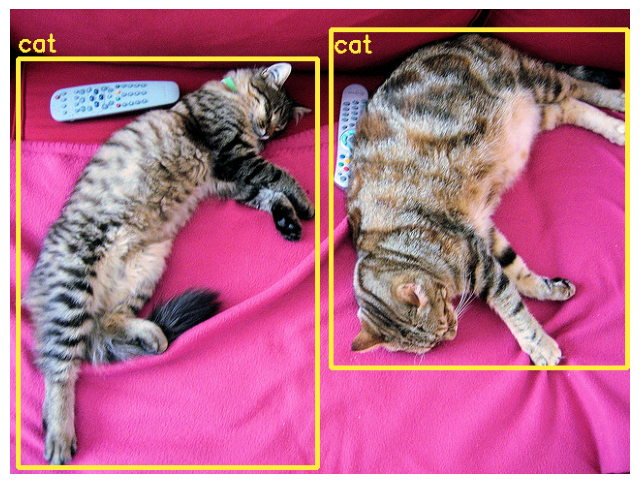

[{'box_2d': [107, 13, 987, 496], 'label': 'cat'},
 {'box_2d': [45, 518, 772, 996], 'label': 'cat'}]

In [ ]:
PROMPT_DETECTION = (
    "<|turn>user\n"
    "<|image|>\n"
    "Identify every cat in this image. First give one short sentence, then\n"
    "return a JSON array inside a ```json``` block. Each item must contain\n"
    "<|turn>model\n"
)
detection_output = model.generate(
    {"prompts": [PROMPT_DETECTION], "images": [image]},
    max_length=2048,
)
raw_detection_text = strip_prompt(detection_output, PROMPT_DETECTION)
display_model_response(raw_detection_text)

parsed_detections = render_detection_result(image, raw_detection_text)
parsed_detections


## 7. Native Audio Understanding: Speech Transcription (ASR)

Gemma 4 processes raw audio waveforms natively via the `<|audio|>` token without requiring an external speech-to-text model:


In [ ]:
PROMPT_AUDIO = (
    "<|turn>user\n"
    "<|audio|>"
    "Transcribe the following speech segment in its original language. "
    "Follow these specific instructions for formatting the answer:\n"
    "* Only output the transcription, with no newlines.\n"
    "* When transcribing numbers, write the digits, i.e. write 1.7\n"
    " and not one point seven, and write 3 instead of three.<turn|>\n"
    "<|turn>model\n"
)

audio_path = "female_short_voice_clip_17sec.wav"
if not os.path.exists(audio_path):
    print("Downloading audio file...")
    response = requests.get(AUDIO_URL)
    with open(audio_path, "wb") as f:
        f.write(response.content)

audio = load_audio(audio_path)
print("Audio shape:", audio.shape, "dtype:", audio.dtype)
audio_output = model.generate(
    {"prompts": [PROMPT_AUDIO], "audio": [audio]},
    max_length=2048,
)
display_model_response(strip_prompt(audio_output, PROMPT_AUDIO))


Audio shape: (282958,) dtype: float32


> **Model response**

Intelligence is a multifaceted ability encompassing reasoning, learning, problem-solving, abstraction, creativity, and adaptation, allowing organisms or systems to process information, recognize patterns, form connections, and navigate complex environments efficiently.

## 8. Structured Tool Use & Function Calling

Gemma 4 supports tool declarations in the system prompt. The model autonomously decides when to invoke external functions by generating structured tool call requests:


In [ ]:
PROMPT_FUNC_CALL = (
    "<|turn>system\n"
    "You are a helpful assistant."
    "<|tool>declaration:get_current_weather{"
    'description:<|"|>Returns the current weather for a given city.,'
    "parameters:{"
    'location:{type:<|"|>string<|"|>,description:<|"|>The city name<|"|>}'
    "}}"
    "<tool|><turn|>\n"
    "<|turn>user\n"
    "What is the weather like in Paris right now?<turn|>\n"
    "<|turn>model\n"
)

tool_call_output = model.generate({"prompts": [PROMPT_FUNC_CALL]}, max_length=256)
tool_call_text = (
    tool_call_output[0] if isinstance(tool_call_output, list) else tool_call_output
)
tool_call_text = tool_call_text.split("<|turn>model\n")[-1]
print(tool_call_text)

PROMPT_WITH_RESPONSE = (
    PROMPT_FUNC_CALL
    + '<|tool_call>call:get_current_weather{location:<|"|>Paris<|"|>}'
    + "<tool_call|><|tool_response>response:get_current_weather{"
    + 'temperature:18,weather:<|"|>partly cloudy<|"|>}<tool_response|>\n'
    + "<|turn>model\n"
)

final_weather_output = model.generate(
    {"prompts": [PROMPT_WITH_RESPONSE]}, max_length=256
)
final_weather_text = (
    final_weather_output[0]
    if isinstance(final_weather_output, list)
    else final_weather_output
)
final_weather_text = final_weather_text.split("<|turn>model\n")[-1]
display_model_response(final_weather_text)


<|tool_call>call:get_current_weather{location:<|"|>Paris<|"|>}<tool_call|><|tool_response>


> **Model response**

The weather in Paris right now is partly cloudy with a temperature of 18 degrees.

## 9. Code Generation & Algorithmic Synthesis

We test Gemma 4's programming capabilities by generating a self-contained Python function with comprehensive edge-case handling and assertions:


In [ ]:
PROMPT_CODE = (
    "<|turn>user\n"
    "Write a Python function named `is_palindrome` that ignores\n"
    "punctuation, whitespace, and letter casing. Also include a few\n"
    "short test calls.<turn|>\n"
    "<|turn>model\n"
)

code_output = model.generate({"prompts": [PROMPT_CODE]}, max_length=512)
display_model_response(strip_prompt(code_output, PROMPT_CODE))


> **Model response**

```python
import re

def is_palindrome(text):
    """
    Checks if a given string is a palindrome, ignoring punctuation, 
    whitespace, and letter casing.

    Args:
        text (str): The input string to check.

    Returns:
        bool: True if the string is a palindrome, False otherwise.
    """
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove all non-alphanumeric characters (punctuation and whitespace)
    # re.sub(pattern, replacement, string) replaces all matches of the pattern
    cleaned_text = re.sub(r'[^a-z0-9]', '', text)
    
    # 3. Check if the cleaned string is equal to its reverse
    return cleaned_text == cleaned_text[::-1]

## --- Test Calls ---

print("--- Testing is_palindrome function ---")

## Test Case 1: Simple palindrome (should be True)
test1 = "Racecar"
print(f"'{test1}': {is_palindrome(test1)}")  # Expected: True

## Test Case 2: Palindrome with mixed case and spaces (should be True)
test2 = "A man a plan a canal Panama"
print(f"'{test2}': {is_palindrome(test2)}")  # Expected: True

## Test Case 3: Not a palindrome (should be False)
test3 = "hello world"
print(f"'{test3}': {is_palindrome(test3)}")  # Expected: False

## Test Case 4: Palindrome with numbers and punctuation (should be True)
test4 = "Madam, I'm Adam"
print(f"'{test4}': {is_palindrome(test4)}")  # Expected: True (madamimadam)

## Test Case 5: Empty string (should be True, as an empty string is a palindrome)
test5 = ""
print(f"'{test5}': {is_palindrome(test5)}")  # Expected: True

## Test Case 6: Complex non-palindrome (should

## 10. Thinking Mode & Agentic Workflows

Gemma 4 incorporates an internal **Thinking Mode**. When facing complex, multi-step agentic scenarios, the model emits explicit reasoning traces wrapped in `<|thought|>` tags before executing tools and actions:


In [ ]:
# Mock tools
def control_device(room, device, action):
    return f"Success: {device} in {room} is now {action}."


def read_sensor(room, sensor_type):
    if sensor_type == "temperature":
        return "22°C"
    elif sensor_type == "humidity":
        return "45%"
    return "Unknown sensor"


tools = {"control_device": control_device, "read_sensor": read_sensor}

PROMPT_AGENT = (
    "<|turn>system\n"
    "<|think|>You are a helpful smart home assistant."
    "<|tool>declaration:control_device{"
    "description:<|\"|>Control a smart home device.<|\"|>,"
    "parameters:{"
    "room:{type:<|\"|>string<|\"|>,description:<|\"|>The room name<|\"|>},"
    "device:{type:<|\"|>string<|\"|>,description:<|\"|>The device name (e.g., lights, fan)<|\"|>},"
    "action:{type:<|\"|>string<|\"|>,description:<|\"|>The action (on, off)<|\"|>}"
    "}}"
    "<|tool>declaration:read_sensor{"
    "description:<|\"|>Read a sensor value.<|\"|>,"
    "parameters:{"
    "room:{type:<|\"|>string<|\"|>,description:<|\"|>The room name<|\"|>},"
    "sensor_type:{type:<|\"|>string<|\"|>,description:<|\"|>The sensor type (temperature, humidity)<|\"|>}"
    "}}"
    "<tool|><turn|>\n"
    "<|turn>user\n"
    "Turn off the kitchen lights by setting action='off' and check the\n"
    "temperature in the bedroom by setting sensor_type='temperature'.<turn|>\n"
    "<|turn>model\n"
)


def run_agent_loop(prompt):
    conversation = prompt
    max_turns = 5

    for turn in range(max_turns):
        print(f"\n--- Agent Turn {turn + 1} ---")
        output = model.generate({"prompts": [conversation]}, max_length=1024)
        generated_text = strip_prompt(output, conversation)
        if not generated_text:
            print("\nAgent finished or no output.")
            break

        display_model_response(generated_text, title=f"Model response, turn {turn + 1}")

        # Check for tool calls
        matches = re.findall(
            r"<\|tool_call>(.*?)<tool_call\|>", generated_text, flags=re.DOTALL
        )
        if matches:
            conversation += generated_text
            for call_str in matches:
                call_match = re.search(r"call:(\w+)\{(.*?)\}", call_str)
                if call_match:
                    tool_name = call_match.group(1)
                    args_str = call_match.group(2)
                    args = {}
                    for pair in args_str.split(","):
                        join_pair = pair.split(":")
                        if len(join_pair) == 2:
                            val = join_pair[1].strip()
                            val = val.replace('<|"|>', "").replace(
                                "<||>", ""
                            )
                            args[join_pair[0].strip()] = val

                    print(f"\nExecuting tool: {tool_name} with args {args}")
                    if tool_name in tools:
                        result = tools[tool_name](**args)
                        print(f"Tool Result: {result}")
                        conversation += f"<|tool_response>response:{tool_name}{{{result}}}<tool_response|>\n"
                    else:
                        print(f"Error: Tool {tool_name} not found.")
                        break
                else:
                    print("Error: Malformed tool call.")
                    break
            conversation += "<|turn>model\n"
        else:
            print("\nAgent finished or no tool call.")
            break


run_agent_loop(PROMPT_AGENT)



--- Agent Turn 1 ---


> **Model response, turn 1**

<|channel>thought
1. **Analyze the user request:** The user has two distinct requests:
    * "Turn off the kitchen lights by setting action='off'".
    * "check the temperature in the bedroom by setting sensor_type='temperature'".

2. **Identify necessary tools:**
    * To turn off lights, the `control_device` tool is relevant.
    * To check the temperature, the `read_sensor` tool is relevant.

3. **Process the first request ("Turn off the kitchen lights"):**
    * **Tool:** `control_device`
    * **`device`:** "lights" (implied by "kitchen lights")
    * **`room`:** "kitchen"
    * **`action`:** "off"
    * **Construct the tool call:** `control_device(room='kitchen', device='lights', action='off')`

4. **Process the second request ("check the temperature in the bedroom"):**
    * **Tool:** `read_sensor`
    * **`sensor_type`:** "temperature"
    * **`room`:** "bedroom"
    * **Construct the tool call:** `read_sensor(room='bedroom', sensor_type='temperature')`

5. **Combine the tool calls:** The user requested both actions in a single prompt, so both tool calls should be generated.

6. **Format the output:** Present the tool calls in the required JSON format.<|tool_call>call:control_device{room:<|"|>kitchen<|"|>,device:<|"|>lights<|"|>,action:<|"|>off<|"|>}<tool_call|><|tool_call>call:read_sensor{room:<|"|>bedroom<|"|>,sensor_type:<|"|>temperature<|"|>}<tool_call|>


Executing tool: control_device with args {'room': 'kitchen', 'device': 'lights', 'action': 'off'}
Tool Result: Success: lights in kitchen is now off.

Executing tool: read_sensor with args {'room': 'bedroom', 'sensor_type': 'temperature'}
Tool Result: 22°C

--- Agent Turn 2 ---


> **Model response, turn 2**

The kitchen lights have been turned off, and the temperature in the bedroom is 22°C.


Agent finished or no tool call.


## 11. Multi-Image Comparative Reasoning

Gemma 4 can evaluate and compare multiple images concurrently, identifying similarities, differences, and contextual nuances across visual inputs:


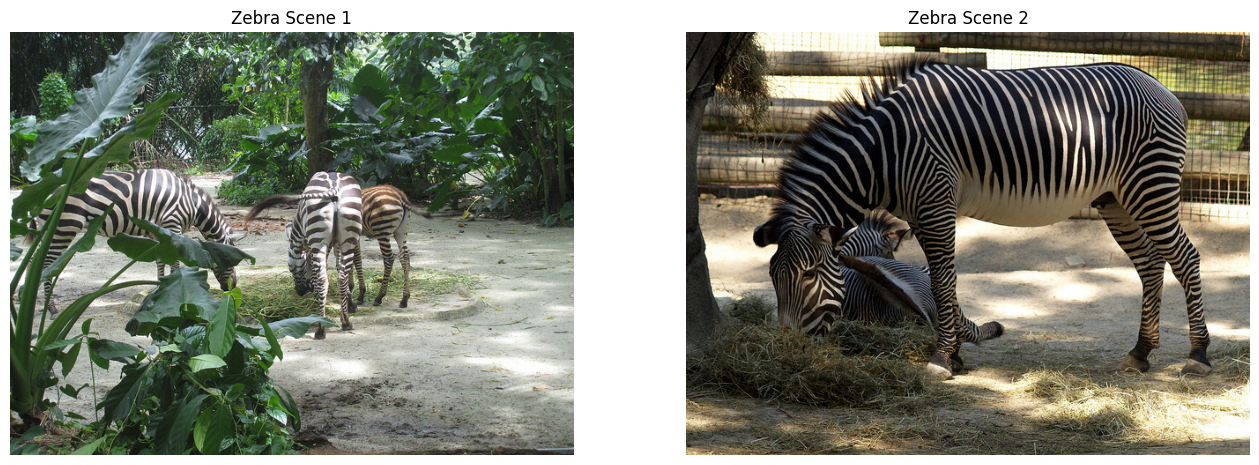

> **Model response**

The two images depict zebras in different settings, showcasing variations in the environment and the animals' behavior.

**Image 1 Analysis:**
*   **Setting:** This scene appears to be in a more natural or semi-natural, lush, and shaded environment. There is dense green foliage, large leaves in the foreground, and trees in the background, suggesting a jungle or woodland setting. The ground is dirt/sand mixed with some sparse grass.
*   **Animals:** There are at least three zebras visible. Two are standing in the middle ground, and one is partially visible on the left. They appear to be standing relatively calmly, perhaps grazing or observing their surroundings.
*   **Interaction:** The zebras seem to be existing within the dense vegetation. The overall mood is one of quiet coexistence within a rich, green habitat.

**Image 2 Analysis:**
*   **Setting:** This scene is clearly an enclosure, likely a zoo or wildlife park. There is a visible wire or mesh fence in the background, and the ground is dry, sandy earth with patches of dry grass. The lighting suggests bright, direct sunlight.
*   **Animals:** There are several zebras visible. The most prominent zebra in the foreground is standing and facing the viewer, showcasing its distinct black and white stripes clearly. Other zebras are visible in the background, some of which appear to be lying down or resting on hay/straw.
*   **Interaction:** The animals in this scene seem more accustomed to human proximity (implied by the enclosure). The zebra in the foreground is alert and facing outward, while others are resting. The interaction is more defined by the boundary of the enclosure and the presence of managed resources (like the hay).

**Key Differences Summarized:**

1.  **Environment:** Image 1 is characterized by dense, natural, and lush vegetation, while Image 2 is an open, dry enclosure with visible fencing.
2.  **Lighting/Atmosphere:** Image 1 is shaded and dappled, creating a cooler, more enclosed feel. Image 2 is brightly lit by direct sunlight.
3.  **Animal Posture/Activity:** In Image 1, the animals appear more integrated into the natural setting. In Image 2, the animals are situated within a defined boundary, and some are resting on provided bedding (hay).
4.  **Focus:** Image 1 emphasizes the wild, overgrown aspect of the habitat, whereas Image 2 emphasizes the managed aspect of the animal's living space.

In [ ]:
ZEBRA_URL_1 = "http://images.cocodataset.org/val2017/000000113354.jpg"
ZEBRA_URL_2 = "http://images.cocodataset.org/val2017/000000104455.jpg"

image_1 = load_image(ZEBRA_URL_1)
image_2 = load_image(ZEBRA_URL_2)
display_images([image_1, image_2], titles=["Zebra Scene 1", "Zebra Scene 2"])

PROMPT_COMPARE = (
    "<|turn>user\n"
    "<|image|>\n"
    "<|image|>\n"
    "These images show the same type of animal in different environments.\n"
    "Describe the differences in the scenes and how the animals appear\n"
    "to be interacting with their surroundings.<turn|>\n"
    "<|turn>model\n"
)

comparison_output = model.generate(
    {"prompts": [PROMPT_COMPARE], "images": [[np.array(image_1), np.array(image_2)]]},
    max_length=2048,
)
display_model_response(strip_prompt(comparison_output, PROMPT_COMPARE))


## 12. Visual Document Understanding: OCR, Translation & Entity Extraction

Gemma 4 reads text embedded in real-world scenes, translates content across languages, and extracts structured key-value entities:


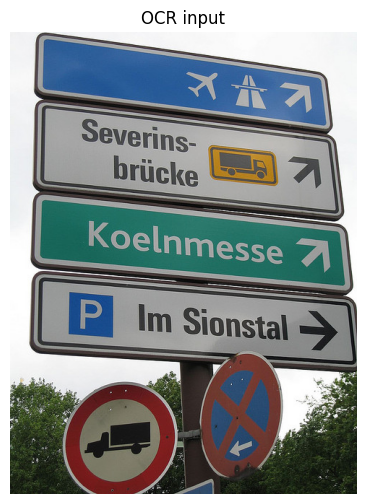

> **Model response**

Here is the extracted text, entity identification, and translation:

### Extracted Text (German)

* Severins-brücke
* Koelnmesse
* Im Sionstal

### Entities and English Translations

| German Entity | English Translation | Type |
| :--- | :--- | :--- |
| Severins-brücke | Severin Bridge | Place Name |
| Koelnmesse | Cologne Exhibition Centre (or Koelnmesse) | Place Name/Venue |
| Im Sionstal | In the Sion Valley | Place Name |

In [ ]:
OCR_IMAGE_URL = "http://images.cocodataset.org/val2017/000000011615.jpg"
ocr_image = load_image(OCR_IMAGE_URL)
display_images(ocr_image, titles=["OCR input"])

PROMPT_OCR = (
    "<|turn>user\n"
    "<|image|>\n"
    "Extract the text from this image. First, transcribe all text in its\n"
    "original language (German). Then, identify the entities (place names\n"
    "like 'Severins-brücke') and provide their English translation.\n"
    "Format the output clearly.<turn|>\n"
    "<|turn>model\n"
)

ocr_output = model.generate(
    {"prompts": [PROMPT_OCR], "images": [ocr_image]},
    max_length=2048,
)
display_model_response(strip_prompt(ocr_output, PROMPT_OCR))


## 13. Real-World Visual Planning: Contextual Travel Itinerary

Given a photograph of a landmark or destination, Gemma 4 recognizes the location and synthesizes actionable recommendations:


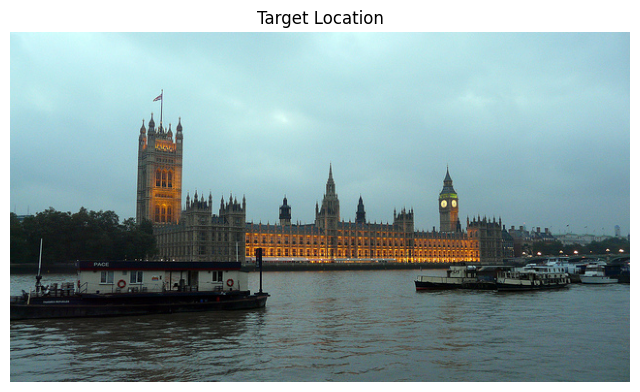

> **Model response**

### Location Identification

The image displays the **Palace of Westminster** (including the Houses of Parliament) and the **Elizabeth Tower** (housing Big Ben) on the River Thames in **London, United Kingdom**.

---

### 3-Day London Travel Plan

This itinerary balances iconic historical sightseeing, cultural experiences, and London's vibrant atmosphere.

#### Day 1: Royal & Political History

**Theme:** Iconic Landmarks and Westminster History

*   **Morning (9:00 AM - 1:00 PM):** **Westminster Abbey.** Start your day at this magnificent Gothic church, the site of coronations, royal weddings, and burials. (Book tickets in advance).
*   **Lunch (1:00 PM - 2:00 PM):** Grab a traditional pub lunch near Westminster, perhaps in the area around Whitehall.
*   **Afternoon (2:00 PM - 5:00 PM):** **Houses of Parliament & Big Ben.** Take photos of the Palace of Westminster and the iconic Elizabeth Tower. Walk along the South Bank to see the surrounding political architecture.
*   **Late Afternoon (5:00 PM - 7:00 PM):** **Walk along the South Bank.** Enjoy the views of the Thames and the bridges.
*   **Evening:** **Dinner in Covent Garden.** Explore the lively market area for diverse dining options and street performers.

**🍽️ Restaurant Suggestions for Day 1:**
*   **The Red Lion (Near Westminster):** For classic, traditional British pub fare.
*   **Dishoom (Covent Garden/Shoreditch):** Excellent, vibrant Bombay Café style food.

#### Day 2: Royal Grandeur & Museum Culture

**Theme:** Royal Parks, Museums, and Culture

*   **Morning (9:30 AM - 1:00 PM):** **Buckingham Palace & St. James's Park.** Visit the official residence of the monarch. Afterwards, stroll through the beautiful St. James's Park. (Check the schedule for the Changing of the Guard if applicable).
*   **Lunch (1:00 PM - 2:00 PM):** Casual lunch near Trafalgar Square.
*   **Afternoon (2:00 PM - 5:00 PM):** **The National Gallery (Trafalgar Square).** Spend the afternoon immersing yourself in world-class art collections.
*   **Late Afternoon (5:00 PM - 7:00 PM):** **Trafalgar Square & Nelson's Column.** Enjoy the atmosphere and perhaps visit the nearby National Portrait Gallery.
*   **Evening:** **Dinner in Soho.** Explore this area for trendy restaurants, theatre, and nightlife.

**🍽️ Restaurant Suggestions for Day 2:**
*   **Sketch (Mayfair):** For a truly unique, high-end dining experience (if budget allows).
*   **Balthazar (Covent Garden):** Classic French bistro atmosphere.

#### Day 3: History, Markets, and River Life

**Theme:** Markets, History, and Thames Experience

*   **Morning (9:30 AM - 12:30 PM):** **Tower of London.** Explore this historic castle, home to the Crown Jewels, and learn about its dark and fascinating history. (Allow at least 3 hours).
*   **Lunch (12:30 PM - 1:30 PM):** Lunch near the Tower or Borough Market area.
*   **Afternoon (1:30 PM - 4:30 PM):** **Borough Market Exploration.** Dive into this famous food market for sampling local produce, cheeses, and snacks.
*   **Late Afternoon (4:30 PM - 6:30 PM):** **Thames River Cruise.** Take a relaxing cruise on the Thames to see London from a different perspective, passing landmarks you may have missed.
*   **Evening:** **Farewell Dinner in the City or East London.** Enjoy a final memorable meal.

**🍽️ Restaurant Suggestions for Day 3:**
*   **Borough Market:** Excellent for diverse, high-quality street food and market dining.
*   **The City (Financial District):** For sophisticated, modern dining experiences.

---

#### Essential London Travel Tips

*   **Transportation:** Utilize the **Tube (Underground)** for fast travel between major zones. Purchase an **Oyster Card** or use a contactless payment card for easy travel.
*   **Booking:** Pre-book tickets for major attractions (Westminster Abbey, Tower of London) to save time.
*   **Weather:** London weather is unpredictable. Always carry layers and a waterproof jacket.
*   **Pace:** This is a busy itinerary. Be prepared to move quickly, especially on Day 3.

In [ ]:
LOCATION_URL = "http://images.cocodataset.org/val2017/000000036678.jpg"
location_image = load_image(LOCATION_URL)
display_images(location_image, titles=["Target Location"])

PROMPT_TRAVEL = (
    "<|turn>user\n"
    "<|image|>\n"
    "Identify the location in this image and create a 3-day travel plan\n"
    "for it. Include top attractions and a few restaurant suggestions.\n"
    "Format the output clearly with headings.<turn|>\n"
    "<|turn>model\n"
)

travel_output = model.generate(
    {"prompts": [PROMPT_TRAVEL], "images": [location_image]},
    max_length=2048,
)
display_model_response(strip_prompt(travel_output, PROMPT_TRAVEL))
